In [32]:
import os

import libfmp
import librosa
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

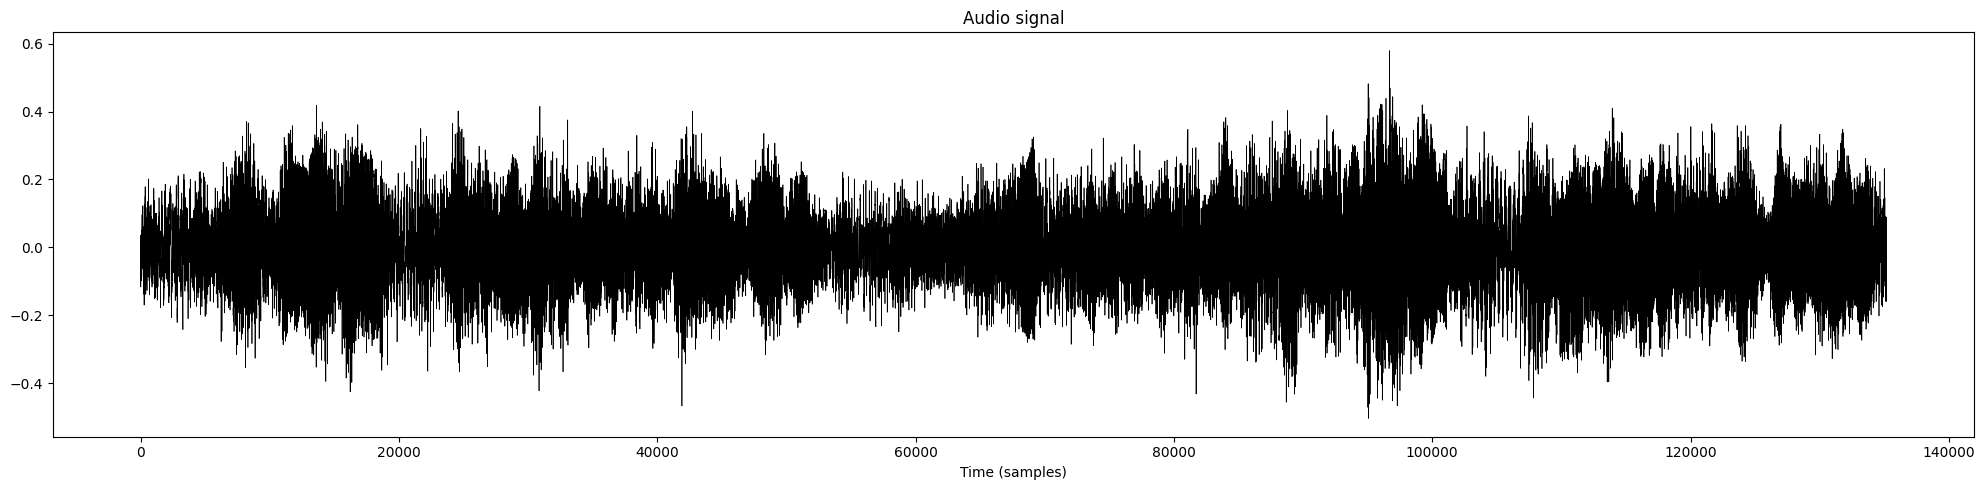

In [33]:
# Signal
fn_wav = os.path.join('data', 'FMP_C6_F07_Shostakovich_Waltz-02-Section_IncreasingTempo.wav')
Fs = 22050
x, Fs = librosa.load(fn_wav, sr=Fs)
x_duration = len(x) / Fs

# Plot signal
fig = plt.figure(figsize=(20, 5))
plt.plot(x, 'k', linewidth=0.5)
plt.title('Audio signal')
plt.xlabel('Time (samples)')
plt.tight_layout()

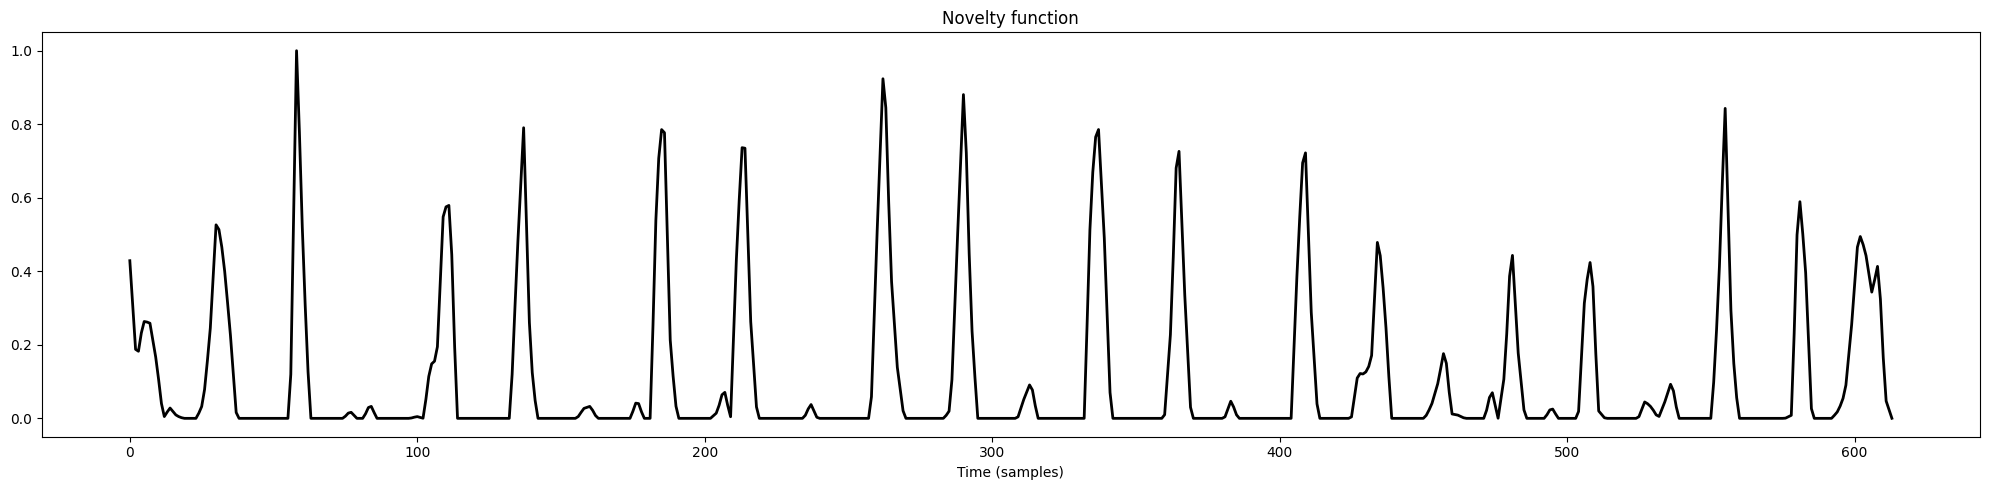

In [34]:
nov, Fs_nov = libfmp.c6.compute_novelty_spectrum(x, Fs=Fs, N=2048, H=512, gamma=100, M=10, norm=1)
nov, Fs_nov = libfmp.c6.resample_signal(nov, Fs_in=Fs_nov, Fs_out=100)

# Plot signal
fig = plt.figure(figsize=(20, 5))
plt.plot(nov, 'k', linewidth=2)
plt.title('Novelty function')
plt.xlabel('Time (samples)')
plt.tight_layout()

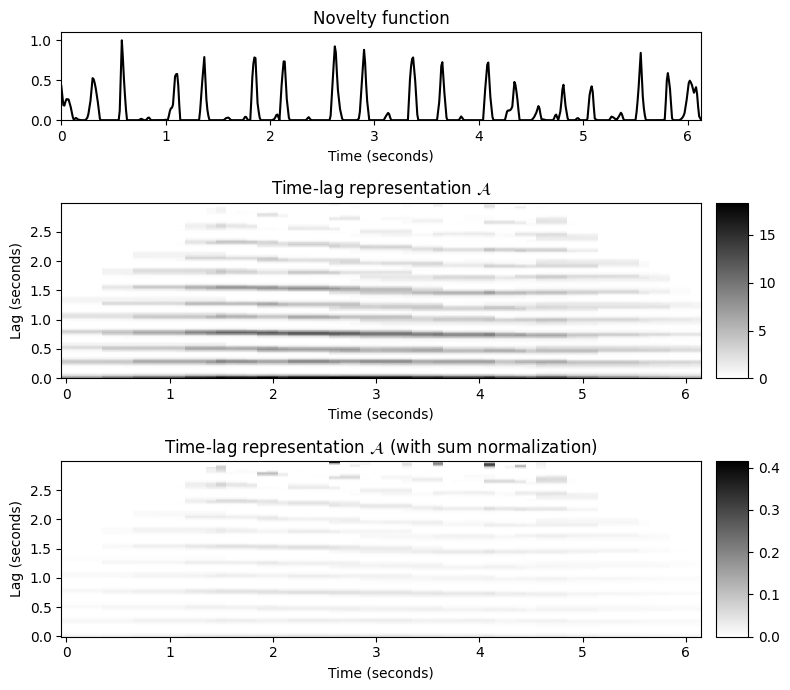

In [31]:
def compute_autocorrelation_local(x, Fs, N, H, norm_sum=True):
    """
    Args:
        x (np.ndarray): Input signal
        Fs (scalar): Sampling rate
        N (int): Window length
        H (int): Hop size
        norm_sum (bool): Normalizes by the number of summands in local autocorrelation (Default value = True)

    Returns:
        A (np.ndarray): Time-lag representation
        T_coef (np.ndarray): Time axis (seconds)
        F_coef_lag (np.ndarray): Lag axis
    """
    # L = len(x)
    L_left = round(N / 2)
    L_right = L_left
    x_pad = np.concatenate((np.zeros(L_left), x, np.zeros(L_right)))
    L_pad = len(x_pad)
    M = int(np.floor(L_pad - N) / H) + 1
    A = np.zeros((N, M))
    win = np.ones(N)
    if norm_sum is True:
        lag_summand_num = np.arange(N, 0, -1)
    for n in range(M):
        t_0 = n * H
        t_1 = t_0 + N
        x_local = win * x_pad[t_0:t_1]
        r_xx = np.correlate(x_local, x_local, mode='full')
        r_xx = r_xx[N - 1:]
        if norm_sum is True:
            r_xx = r_xx / lag_summand_num
        A[:, n] = r_xx
    Fs_A = Fs / H
    T_coef = np.arange(A.shape[1]) / Fs_A
    F_coef_lag = np.arange(N) / Fs
    return A, T_coef, F_coef_lag


#Autocorrelation parameters
N = 300  #corresponding to 3 seconds (Fs_nov = 100 Hz)
H = 10

A, T_coef, F_coef_lag = compute_autocorrelation_local(nov, Fs_nov, N, H, norm_sum=False)
A_norm, T_coef, F_coef_lag = compute_autocorrelation_local(nov, Fs_nov, N, H)

fig, ax = plt.subplots(3, 2, gridspec_kw={'width_ratios': [1, 0.05],
                                          'height_ratios': [1, 2, 2]}, figsize=(8, 7))

libfmp.b.plot_signal(nov, Fs_nov, ax=ax[0, 0], color='k', title='Novelty function')
ax[0, 1].set_axis_off()

libfmp.b.plot_matrix(A, ax=[ax[1, 0], ax[1, 1]], T_coef=T_coef, F_coef=F_coef_lag,
                     title=r'Time-lag representation $\mathcal{A}$', ylabel='Lag (seconds)', colorbar=True);

libfmp.b.plot_matrix(A_norm, ax=[ax[2, 0], ax[2, 1]], T_coef=T_coef, F_coef=F_coef_lag,
                     title=r'Time-lag representation $\mathcal{A}$ (with sum normalization)',
                     ylabel='Lag (seconds)', colorbar=True);
plt.tight_layout()

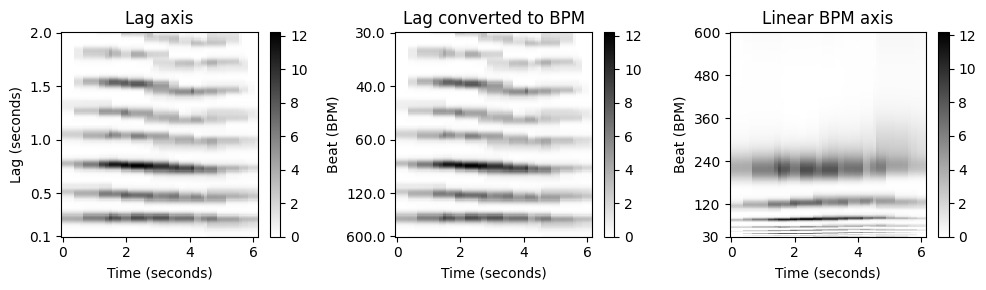

In [36]:
def compute_tempogram_autocorr(x, Fs, N, H, norm_sum=False, Theta=np.arange(30, 601)):
    """
    Args:
        x (np.ndarray): Input signal
        Fs (scalar): Sampling rate
        N (int): Window length
        H (int): Hop size
        norm_sum (bool): Normalizes by the number of summands in local autocorrelation (Default value = False)
        Theta (np.ndarray): Set of tempi (given in BPM) (Default value = np.arange(30, 601))

    Returns:
        tempogram (np.ndarray): Tempogram tempogram
        T_coef (np.ndarray): Time axis T_coef (seconds)
        F_coef_BPM (np.ndarray): Tempo axis F_coef_BPM (BPM)
        A_cut (np.ndarray): Time-lag representation A_cut (cut according to Theta)
        F_coef_lag_cut (np.ndarray): Lag axis F_coef_lag_cut
    """
    tempo_min = Theta[0]
    tempo_max = Theta[-1]
    lag_min = int(np.ceil(Fs * 60 / tempo_max))
    lag_max = int(np.ceil(Fs * 60 / tempo_min))
    A, T_coef, F_coef_lag = compute_autocorrelation_local(x, Fs, N, H, norm_sum=norm_sum)
    A_cut = A[lag_min:lag_max + 1, :]
    F_coef_lag_cut = F_coef_lag[lag_min:lag_max + 1]
    F_coef_BPM_cut = 60 / F_coef_lag_cut
    F_coef_BPM = Theta
    tempogram = interp1d(F_coef_BPM_cut, A_cut, kind='linear',
                         axis=0, fill_value='extrapolate')(F_coef_BPM)
    return tempogram, T_coef, F_coef_BPM, A_cut, F_coef_lag_cut


Theta = np.arange(30, 601)
tempogram, T_coef, F_coef, A, F_coef_lag = compute_tempogram_autocorr(nov,
                                                                      Fs_nov, N, H, norm_sum=False, Theta=Theta)

fig, ax = plt.subplots(1, 3, gridspec_kw={'width_ratios': [1, 1, 1]}, figsize=(10, 3))

libfmp.b.plot_matrix(A, T_coef=T_coef, F_coef=F_coef_lag, ax=[ax[0]],
                     title='Lag axis', ylabel='Lag (seconds)', colorbar=True);
lag_yticks = np.array([F_coef_lag[0], 0.5, 1.0, 1.5, F_coef_lag[-1]])
ax[0].set_yticks(lag_yticks)

libfmp.b.plot_matrix(A, T_coef=T_coef, F_coef=F_coef_lag, ax=[ax[1]],
                     title='Lag converted to BPM', ylabel='Beat (BPM)', colorbar=True);
ax[1].set_yticks(lag_yticks)
ax[1].set_yticklabels(60 / lag_yticks)

libfmp.b.plot_matrix(tempogram, T_coef=T_coef, F_coef=F_coef, ax=[ax[2]],
                     title='Linear BPM axis', ylabel='Beat (BPM)', colorbar=True);
ax[2].set_yticks([F_coef[0], 120, 240, 360, 480, F_coef[-1]]);
plt.tight_layout()